In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from features import SR, FRAME, HOP, SCALAR_FEATURES, MFCC_FEATURES, CONTEXT_FEATURES, extract_features
from dataset import load_wav, list_clips, speech_labels, mix, build_frame_table
from evaluate import scores, test_single_feature, test_feature_set, fit_model

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

İlk iki satır: src klasörünü Python’a tanıtır. Önceki notebook’larla aynı.
numpy, pandas, matplotlib: Hesap, tablo, grafik.
from features import ...: Bu kez üç feature listesi geliyor:
SCALAR_FEATURES: Tanıdığın yedi feature (energy, zcr, centroid, flatness, flux, band_ratio, harmonicity).
MFCC_FEATURES: 12 MFCC katsayısı. Henüz bakmadık; sırası gelince anlatacağım.
CONTEXT_FEATURES: Her skaler feature’ın çevredeki 0,3 saniyedeki ortalaması ve oynaklığı. Notebook 02'nin son grafiğindeki “konuşma oynak, duraklama düz” gözlemini kullanan feature’lar.
from dataset import ...: Veri yükleme ve tablo kurma. Önceki notebook’larla aynı.
from evaluate import ...: Bu notebook’ta ilk kez kullanıyoruz. Dört fonksiyon:
scores: Tahminleri doğru cevaplarla karşılaştırıp accuracy hesaplar.
test_single_feature: Tek bir feature’a eşik koyup sınar.
test_feature_set: Birkaç feature’ı birlikte kullanıp sınar.
fit_model: Birkaç feature’dan bir model öğrenir.
Son iki satır: Tabloların kaydedileceği results klasörü.

In [2]:
train = build_frame_table("train")
test = build_frame_table("test")
print("Train frames:", len(train), "| Test frames:", len(test))
display(test.groupby(["condition", "klass"]).size().unstack(fill_value=0))

Train frames: 299700 | Test frames: 199800


klass,noise,silence,speech
condition,,,
clean speech,0,6427,33533
noise only,39960,0,0
speech + noise 0 dB,6427,0,33533
speech + noise 10 dB,6427,0,33533
speech + noise 20 dB,6427,0,33533


Ne yapıyor:

build_frame_table("train"): Train klasöründeki 30 konuşma ve 30 gürültü kaydı için bütün parçaların feature’larını ve etiketlerini hesaplar.
build_frame_table("test"): Aynısını test klasöründeki 20 + 20 kayıt için yapar. Notebook 02'de kurduğun tablonun aynısı.
print: İki tablodaki parça sayısını yazar.
display: Test tablosundaki parçaları koşula ve sınıfa göre sayar.

Neden iki ayrı tablo:

Tablo	Ne için kullanılacak
train	Eşikleri ve modelleri öğrenmek için
test	Öğrenilen şeyi sınamak için

Sınav sorularını önceden görmüş bir öğrencinin notu gerçek bilgisini göstermez. Aynı şekilde, eşiği test verisine bakarak seçersek accuracy olduğundan yüksek çıkar. Bu yüzden eşik train’den öğrenilir, hiç görülmemiş test kayıtlarında sınanır.
Nasıl puanlıyoruz

Her parça için bir tahmin yapılır (evet / hayır) ve doğru cevapla karşılaştırılır. Dört sayı çıkar:

Sayı	Anlamı
accuracy	Bütün parçaların yüzde kaçı doğru
balanced_acc	“Evet” parçalarındaki doğruluk ile “hayır” parçalarındaki doğruluğun ortalaması
miss_rate	“Evet” olması gerekirken “hayır” dediğimiz oran (konuşmayı kaçırmak)
false_alarm	“Hayır” olması gerekirken “evet” dediğimiz oran (yanlış alarm)

Ana sayı balanced_acc. Nedeni az önceki tabloda: konuşma parçaları sessizliğin yirmi katı. “Ses var mı” sorusunda her parçaya gözü kapalı “evet” diyen biri düz accuracy’de %97 alır, hiçbir şey bilmediği halde. Balanced accuracy’de aynı kişi tam 0,50 alır.

In [3]:
rows = []
for target in ["audio", "speech"]:
    for feature in SCALAR_FEATURES:
        result = test_single_feature(train, test, feature, target)
        rows.append({"question": f"{target} present?", "feature": feature, **result})
table2 = pd.DataFrame(rows).set_index(["question", "feature"])
display(table2.round(3))
table2.round(4).to_csv(results_dir / "table2_single_features.csv")

accuracy  balanced_acc  miss_rate  false_alarm  \
question        feature                                                       
audio present?  energy_db       0.931         0.945      0.070        0.040   
                zcr             0.802         0.635      0.187        0.543   
                centroid        0.741         0.792      0.263        0.153   
                flatness        0.739         0.792      0.265        0.152   
                flux            0.612         0.536      0.383        0.546   
                band_ratio      0.741         0.598      0.249        0.555   
                harmonicity     0.362         0.600      0.654        0.146   
speech present? energy_db       0.848         0.855      0.165        0.125   
                zcr             0.678         0.610      0.193        0.586   
                centroid        0.749         0.659      0.079        0.602   
                flatness        0.739         0.641      0.075        0.643   
                flux            0.603         0.650      0.488        0.211   
                band_ratio      0.630         0.538      0.193        0.732   
                harmonicity     0.665         0.725      0.451        0.099   

                             threshold         rule  
question        feature                              
audio present?  energy_db      -36.616  above = yes  
                zcr              0.130  below = yes  
                centroid      1401.379  below = yes  
                flatness         0.013  below = yes  
                flux             0.070  above = yes  
                band_ratio       0.156  above = yes  
                harmonicity      0.425  above = yes  
speech present? energy_db      -28.302  above = yes  
                zcr              0.035  above = yes  
                centroid       517.555  above = yes  
                flatness         0.000  above = yes  
                flux             0.072  below = yes  
                band_ratio       0.724  below = yes  
                harmonicity      0.375  above = yes

Ne yapıyor:

for target in ["audio", "speech"]: İki soru için sırayla: önce “ses var mı”, sonra “konuşma var mı”.
for feature in SCALAR_FEATURES: Yedi feature için sırayla. Toplam 2 × 7 = 14 deney.
test_single_feature(train, test, feature, target): Asıl iş. İki adım:
Train verisinde o feature için en iyi eşiği bulur. Hem eşiğin değerini hem yönünü seçer: “eşiğin üstü = evet” mi, “eşiğin altı = evet” mi.
Test verisinde o eşiği uygular ve puanlar.
rows.append(...): Sonucu listeye ekler.
pd.DataFrame(rows): Listeyi tabloya çevirir.
Son satır: results\table2_single_features.csv olarak kaydeder.

Bu, eski deneylerdeki threshold VAD’ın aynısı. Tek farkı: orada yalnızca enerjiye eşik koyuyordun, burada yedi feature’ın her birine ayrı ayrı koyuyoruz.

Beklenen: 14 satırlık bir tablo. Sütunlar: accuracy, balanced_acc, miss_rate, false_alarm, threshold (bulunan eşik), rule (yön: “above = yes” ya da “below = yes”).

Enerji açık ara birinci: 0,945. Eşik −36,6 dB. Notebook 02'de sessizliğin tipik değeri −52, gürültünün −33'tü; eşik ikisinin arasına düşmüş.
Centroid ve flatness ikinci sırada: 0,79. Sessizlikte farklı olduklarını görmüştük, tutuyor.
ZCR beklediğimden zayıf: 0,635. Tablo 1'de sessizlikte iki kat yüksekti, ama histogramda büyük bölümü üst üsteydi. Histogram haklı çıktı.
Harmonicity, band_ratio, flux: 0,54–0,60. Yazı-turaya yakın.

Enerji yine birinci: 0,855. Ama “ses var mı”daki 0,945'ten düşük. Konuşmayı bulmak, sesi bulmaktan zor.
Harmonicity ikinci: 0,725. Sayılarına bak: yanlış alarm yalnızca 0,10, ama kaçırma 0,45. Yani “konuşma” dediğinde büyük ölçüde haklı, ama konuşmanın neredeyse yarısını kaçırıyor. Histogramda gördüğün şeyin aynısı: yüksek harmonicity konuşmadır, düşük harmonicity bir şey söylemez.
Centroid ve flatness ters hata yapıyor. Kaçırma 0,08, yanlış alarm 0,60: neredeyse her şeye “konuşma” diyorlar.

Düz accuracy’ye bakarsan ZCR, harmonicity’den çok daha iyi görünüyor (0,80'e karşı 0,36). Balanced accuracy’de neredeyse aynılar. Neden: ZCR çoğu parçaya “ses var” diyor; parçaların %97'si zaten sesli olduğu için düz accuracy yüksek çıkıyor. Hoca “neden balanced accuracy” diye sorarsa bu iki satırı göster.

Enerji neden “ses var mı”da 1,00 değil?

Bunu henüz ölçmedik; elimde yalnızca olası nedenler var:

20 dB karışımlarda eklenen gürültü çok kısık kalıyor olabilir, eşiğin altında.
Bazı gürültü kayıtları kısık olabilir.
Sessizlik etiketli bazı parçalar (kelime sınırları) eşiğin üstünde olabilir.

Hangisi olduğunu görmek için ayrı bir kontrol gerekir. İstersen notebook’un sonunda ekleriz; şimdilik “nedenini henüz incelemedim” demek en dürüstü.

Bir uyarı

Enerji “konuşma var mı”da 0,855 verdi. Bu, bu verideki gürültü kayıtlarının konuşmadan kısık olmasından kaynaklanıyor olabilir (Tablo 1: gürültü −33, konuşma −22). Gürültü yükseldikçe ne olduğunu Tablo 5'te koşul koşul göreceğiz. O tabloyu görmeden “enerji yeterli” deme.

In [4]:
feature_sets = {
    "energy only": ["energy_db"],
    "7 scalar features": SCALAR_FEATURES,
    "12 MFCC": MFCC_FEATURES,
    "scalar + MFCC": SCALAR_FEATURES + MFCC_FEATURES,
    "scalar + context": SCALAR_FEATURES + CONTEXT_FEATURES,
    "scalar + MFCC + context": SCALAR_FEATURES + MFCC_FEATURES + CONTEXT_FEATURES,
}

rows = []
for target in ["audio", "speech"]:
    for name, features in feature_sets.items():
        result = test_feature_set(train, test, features, target)
        rows.append({"question": f"{target} present?", "feature set": name, "n_features": len(features), **result})
table3 = pd.DataFrame(rows).set_index(["question", "feature set"])
display(table3.round(3))
table3.round(4).to_csv(results_dir / "table3_feature_sets.csv")

n_features  accuracy  balanced_acc  \
question        feature set                                                   
audio present?  energy only                       1     0.945         0.947   
                7 scalar features                 7     0.951         0.955   
                12 MFCC                          12     0.828         0.847   
                scalar + MFCC                    19     0.955         0.958   
                scalar + context                 21     0.957         0.963   
                scalar + MFCC + context          33     0.962         0.963   
speech present? energy only                       1     0.841         0.852   
                7 scalar features                 7     0.881         0.881   
                12 MFCC                          12     0.734         0.735   
                scalar + MFCC                    19     0.894         0.891   
                scalar + context                 21     0.918         0.917   
                scalar + MFCC + context          33     0.923         0.922   

                                         miss_rate  false_alarm  
question        feature set                                      
audio present?  energy only                  0.056        0.050  
                7 scalar features            0.049        0.041  
                12 MFCC                      0.174        0.133  
                scalar + MFCC                0.045        0.040  
                scalar + context             0.043        0.031  
                scalar + MFCC + context      0.038        0.036  
speech present? energy only                  0.181        0.115  
                7 scalar features            0.119        0.119  
                12 MFCC                      0.267        0.263  
                scalar + MFCC                0.099        0.119  
                scalar + context             0.081        0.084  
                scalar + MFCC + context      0.075        0.080

Feature’ları nasıl birleştiriyoruz

Tek feature’da kural basitti: “enerji −28'in üstündeyse konuşma.” İki feature olunca tek bir eşik yetmez. Bunun için logistic regression kullanıyoruz.

Fikir: Her feature’a bir ağırlık ver, hepsini topla, toplam yeterince büyükse “evet” de.

puan = (ağırlık1 × enerji) + (ağırlık2 × harmonicity) + ... + sabit
puan > 0 ise → konuşma var

Bir örnekle:

Kısık ama perdeli bir parça: enerji düşük (eksi puan), harmonicity yüksek (artı puan). Toplam artıda kalabilir → konuşma.
Yüksek sesli ama perdesiz bir gürültü: enerji yüksek (artı), harmonicity düşük (eksi). Toplam eksiye düşebilir → konuşma değil.

Yani bir feature’ın kaçırdığını diğeri telafi edebiliyor.

Ağırlıkları kim seçiyor: Biz değil. Model train verisine bakıp en az hata yapan ağırlıkları kendisi buluyor. Tek feature’da eşiği train’den öğrenmiştik; bu onun çok feature’lı hali.

Bir ön hazırlık: Enerji −50 ile −10 arasında, centroid 500 ile 3000 arasında, flatness 0 ile 0,1 arasında. Bu haliyle toplarsak büyük sayılı feature diğerlerini ezer. O yüzden önce hepsi aynı ölçeğe getiriliyor (StandardScaler). Bunların hepsi evaluate.py içindeki fit_model fonksiyonunda.


Ne yapıyor:

feature_sets: Denenecek altı grup. Küçükten büyüğe:
Set	İçinde ne var	Kaç feature
energy only	Yalnızca enerji	1
7 scalar features	Tanıdığın yedi feature	7
12 MFCC	Yalnızca MFCC’ler	12
scalar + MFCC	İkisi birlikte	19
scalar + context	Yedi feature ve çevre bilgileri	21
scalar + MFCC + context	Hepsi	33
İki for: İki soru × altı set = 12 deney.
test_feature_set(train, test, features, target): Train’de ağırlıkları öğrenir, test’te puanlar.
Son satırlar: Tabloyu gösterir ve results\table3_feature_sets.csv olarak kaydeder.


Yedi feature birlikte enerjiden iyi mi? Evet: 0,852 → 0,881. Beklentimiz tuttu; diğer feature’lar enerjinin kaçırdığının bir kısmını telafi ediyor.
MFCC bir şey katıyor mu? Çok az: +0,010, üstelik 12 feature ekleyerek. Tek başına ise 0,735; tek başına enerjiden (0,852) bile kötü.
Context bir şey katıyor mu? Evet, en çok o katıyor: 0,881 → 0,917.
En büyük sıçrama: Context (+0,036), ardından enerjiye diğer skalerleri eklemek (+0,029).

Kaçırılan konuşma %18'den %7,5'e indi. Yarıdan fazla azaldı.
Baştan sona toplam kazanç 0,016. 32 feature eklemek neredeyse hiçbir şey değiştirmiyor. Bu soru enerjinin işi.

MFCC neden zayıf çıktı?

Ölçtüğümüz şey: MFCC tek başına 0,735, eklenince +0,010.

Olası bir neden: features.py içinde MFCC’nin ilk katsayısını bilerek atıyoruz, çünkü o katsayı ses seviyesini taşıyor. Yani MFCC’lerin içinde enerji bilgisi yok, yalnızca spektrumun biçimi var. En güçlü feature enerji olduğuna göre, enerjisiz bir grubun zayıf kalması şaşırtıcı değil. Ama bu bir açıklama denemesi; doğrulamak için ilk katsayıyı ekleyip yeniden denemek gerekir.

Dikkat edilecek iki şey

Küçük farkları yorumlama. 0,917 ile 0,922 arasındaki 0,005'lik fark gerçek bir üstünlük olmayabilir. Tek bir train/test bölmesi ve 20 test kaydıyla çalışıyoruz; başka kayıtlarla bu fark tersine dönebilir. 0,03 ve üstü farklara güven, 0,01 altını “fark yok” say.

“Energy only” burada 0,852, Tablo 2'de 0,855'ti. Hata değil. İkisi de yalnızca enerjiyi kullanıyor ama eşiği biraz farklı yöntemle seçiyor; sonuç pratikte aynı.

In [5]:
baseline = test_feature_set(train, test, SCALAR_FEATURES, "speech")["balanced_acc"]
rows = [{"features": "all 7", "balanced_acc": baseline, "change": 0.0}]
for removed in SCALAR_FEATURES:
    kept = [f for f in SCALAR_FEATURES if f != removed]
    value = test_feature_set(train, test, kept, "speech")["balanced_acc"]
    rows.append({"features": f"without {removed}", "balanced_acc": value, "change": value - baseline})
table4 = pd.DataFrame(rows).set_index("features")
display(table4.round(3))
table4.round(4).to_csv(results_dir / "table4_remove_one_feature.csv")

,balanced_acc,change
features,,
all 7,0.881,0.000
without energy_db,0.768,-0.113
without zcr,0.870,-0.011
without centroid,0.868,-0.013
without flatness,0.880,-0.001
without flux,0.880,-0.000
without band_ratio,0.880,-0.001
without harmonicity,0.874,-0.006


Soru: Yedi feature birlikte 0,881 verdi. Bu yedinin hepsi katkı sağlıyor mu, yoksa bazıları fazlalık mı?

Yöntem: Feature’ları birer birer çıkarıp sonucun ne kadar düştüğüne bakıyoruz.

Ne yapıyor:

baseline: Yedi feature’ın hepsiyle “konuşma var mı” sonucu. Tablo 3'teki 0,881.
for removed in SCALAR_FEATURES: Yedi feature için sırayla.
kept = [...]: O feature dışındaki altı feature. Örneğin removed enerji ise kept kalan altısı.
test_feature_set(train, test, kept, "speech"): Altı feature ile yeniden eğitir ve sınar.
change: Yeni sonuç eksi 0,881. Eksi çıkarsa o feature’ı çıkarmak zarar vermiş demek.
Son satırlar: Tabloyu gösterir ve results\table4_remove_one_feature.csv olarak kaydeder.

Yalnızca “konuşma var mı” için yapıyoruz. “Ses var mı”da enerji tek başına yettiği için orada sorulacak bir şey kalmadı.

Üç grup

Vazgeçilmez: enerji.
Çıkarınca 0,881'den 0,768'e düşüyor. Diğer hiçbir feature onun yerini tutamıyor.

Küçük katkı: centroid, zcr, harmonicity.
Çıkarınca 0,006 ile 0,013 arası düşüş. Az önce söylediğim gibi, 0,01 civarındaki farklar bu veriyle güvenilir değil. “Belki küçük bir katkıları var” demek en doğrusu.

Fazlalık: flatness, band_ratio, flux.
Çıkarınca hiçbir şey değişmiyor. Taşıdıkları bilgi diğerlerinde zaten var.

Beklenmedik sonuç: harmonicity

Tablo 2'de harmonicity tek başına ikinci en iyi feature’dı (0,725). Burada çıkarınca yalnızca 0,006 kaybediyoruz.

Bu çelişki değil. İki tablo farklı sorular soruyor:

	Soru	Harmonicity
Tablo 2	Tek başına ne kadar iyi?	0,725, ikinci
Tablo 4	Diğer altısı varken ne katıyor?	−0,006, çok az

Tek başına iyi olan bir feature, başkaları aynı bilgiyi taşıyorsa birlikte kullanıldığında fazladan bir şey katmaz. Görünen o ki harmonicity’nin söylediği şeyi diğer feature’lar birlikte zaten söylüyor. Hangileri olduğunu bu tablodan bilemeyiz.

Bir gözlem daha

Enerjisiz altı feature 0,768 veriyor. Bu altısının tek başına en iyisi harmonicity’di, 0,725. Yani enerji olmadan da feature’ları birleştirmek tek tek kullanmaktan iyi.

In [6]:
BEST_SET = SCALAR_FEATURES + MFCC_FEATURES + CONTEXT_FEATURES

speech_model = fit_model(train, BEST_SET, "speech")
test["predicted_speech"] = speech_model.predict(test[BEST_SET].values)

rows = []
for condition, part in test.groupby("condition"):
    is_speech = part["speech"] == 1
    rows.append({
        "condition": condition,
        "speech_found": (part.loc[is_speech, "predicted_speech"] == 1).mean() if is_speech.any() else np.nan,
        "nonspeech_rejected": (part.loc[~is_speech, "predicted_speech"] == 0).mean(),
    })
table5 = pd.DataFrame(rows).set_index("condition")
display(table5.round(3))
table5.round(4).to_csv(results_dir / "table5_by_condition.csv")

,speech_found,nonspeech_rejected
condition,,
clean speech,0.925,0.923
noise only,NaN,0.999
speech + noise 0 dB,0.944,0.531
speech + noise 10 dB,0.918,0.814
speech + noise 20 dB,0.912,0.924


Soru: Tablo 3'te en iyi set 0,922 verdi. Ama bu bütün koşulların ortalaması. Temiz kayıtta mı iyi, 0 dB’de mi kötü?

Ne yapıyor:

BEST_SET: Tablo 3'teki en iyi set: 33 feature’ın hepsi.
fit_model(train, BEST_SET, "speech"): Train verisinde “konuşma var mı” modelini eğitir.
speech_model.predict(...): Test verisindeki her parça için tahmin yapar (1 = konuşma, 0 = değil). Tahminler tabloya predicted_speech adlı yeni bir sütun olarak eklenir.
for condition, part in test.groupby("condition"): Test verisini beş koşula böler ve her biri için ayrı hesap yapar.
speech_found: O koşuldaki konuşma parçalarının yüzde kaçı bulundu. Yüksek olması iyi.
nonspeech_rejected: O koşuldaki konuşma olmayan parçaların yüzde kaçı doğru reddedildi. Yüksek olması iyi.
if is_speech.any() else np.nan: Yalnız gürültü kayıtlarında hiç konuşma yok, o yüzden orada speech_found hesaplanamaz; boş (NaN) yazılır.

Beklenen: Beş satır: clean speech, noise only, 0 dB, 10 dB, 20 dB.

Bakacağın şey: 20 dB’den 0 dB’ye inerken speech_found ne kadar düşüyor?

Sütun sütun

Bulunan konuşma: gürültüden etkilenmiyor.
0,91 ile 0,94 arasında, her koşulda. Gürültü arttıkça düşmesini bekliyordum; düşmüyor. Model konuşmayı kaçırmıyor.

Reddedilen konuşma-dışı: gürültü arttıkça çöküyor.
20 dB’de 0,924 → 10 dB’de 0,814 → 0 dB’de 0,531. Yani 0 dB’de, konuşma olmayan parçaların neredeyse yarısına “konuşma var” diyor.

Ne oluyor?

Karışımlardaki “konuşma-dışı” parçalar, kelimeler arasındaki duraklamalar. Temizde sessizdiler; gürültü ekleyince içleri gürültüyle doldu. 0 dB’de o gürültü konuşmayla aynı seviyede.

Model bu duraklamaları konuşmadan ayıramıyor. Model bozulurken konuşmayı kaçırmıyor; her şeye “konuşma” demeye başlıyor.

En çarpıcı karşılaştırma
	Reddedilen
Yalnız gürültü kayıtları	0,999
0 dB karışımdaki duraklamalar	0,531

İkisi de aynı gürültü kayıtlarından geliyor. Fark şu:

Yalnız gürültü kayıtlarında gürültü kendi doğal seviyesinde, yani kısık (Tablo 1'de −33 dB). Model neredeyse kusursuz reddediyor.
0 dB karışımda aynı gürültü konuşma seviyesine yükseltilmiş. Model yarısına “konuşma” diyor.

Bu, modelin gürültüyü büyük ölçüde kısık olduğu için reddettiğini gösteriyor; gürültünün yapısını tanıdığı için değil. Gürültü yükselince bu dayanak ortadan kalkıyor.

Bunun anlamı

Tablo 3'teki 0,922'yi şimdi daha doğru okuyabiliriz. O sayı beş koşulun karışımı ve içinde modelin çok kolay geçtiği durumlar var (yalnız gürültü: 0,999). Zor durumda, yani yüksek gürültüde, model belirgin biçimde kötü.

Tablo 4'te enerjinin vazgeçilmez çıkması da buna uyuyor: model en çok enerjiye yaslanıyor, enerji de ancak gürültü kısıkken işe yarıyor.

Emin olmadığım kısım

0 dB’deki çöküşün iki olası nedeni var ve hangisinin ne kadar etkili olduğunu ölçmedik:

Enerji. Gürültü konuşma kadar yüksek, enerji ikisini ayıramıyor.
Context. Duraklamalar kısa ve iki yanında konuşma var. Context feature’ları 0,3 saniyelik çevreye baktığı için, duraklamanın ortasındaki bir parçanın çevre ortalamasına komşu konuşma karışıyor.

İkisi birlikte de olabilir. Ayırmak için aynı tabloyu context’siz modelle de hesaplamak gerekir; tek satırlık bir değişiklik, istersen sonra bakarız.

In [7]:
noise_only = test[test["condition"] == "noise only"]
wrongly_speech = noise_only.groupby("clip")["predicted_speech"].mean().sort_values(ascending=False)
display(wrongly_speech.head(5).round(2).to_frame("share of frames called speech"))

worst_clip = wrongly_speech.index[0]
print("Worst noise clip:", worst_clip)
display(Audio(load_wav(Path("../data/test/noise_only") / worst_clip), rate=SR))

,share of frames called speech
clip,
14.wav,0.02
0.wav,0.00
10.wav,0.00
1.wav,0.00
11.wav,0.00


Worst noise clip: 14.wav


Soru: Yalnız gürültü kayıtlarında hiç konuşma yok. Model hangilerinde yanlışlıkla “konuşma var” diyor?

Ne yapıyor:

noise_only: Test verisinden yalnızca gürültü kayıtlarının parçalarını alır.
groupby("clip")["predicted_speech"].mean(): Her gürültü kaydı için, parçalarının yüzde kaçına “konuşma” dendiğini hesaplar. İdeali 0.
sort_values(ascending=False): En kötüden iyiye sıralar.
.head(5): En kötü beş kaydı gösterir.
worst_clip: En kötü kaydın dosya adı.
Son satır: O kaydı çalar.

Beklenen: Beş satırlık bir tablo, bir dosya adı ve bir oynatıcı.

Yapacağın: En kötü kaydı dinle. Tablodaki diğer dosyaları da data\test\noise_only klasöründen açıp dinle. Ne tür sesler bunlar? Neden konuşmaya benziyor olabilirler?

En kötü kayıt bile parçalarının yalnızca %2'sinde yanılıyor.
20 gürültü kaydının geri kalanında oran sıfır.
Tablo 5'teki 0,999 ile tutarlı.
Ne anlama geliyor

Bu hücreyi “dedektörü şaşırtan gürültüleri bul” diye tasarlamıştım. Benim test verimde arka planda insan konuşması olan gürültü kayıtları vardı ve model onlarda çok yanılıyordu. Senin verinde öyle kayıtlar yok; sen de dinlerken yalnızca uğultu duymuştun. O yüzden bu hücre burada ilginç bir şey bulmuyor.

Yine de bir bilgi veriyor: bu verideki gürültüler, kendi seviyelerindeyken model için sorun değil. Sorun Tablo 5'te gördüğümüz gibi gürültü konuşma seviyesine yükseltildiğinde başlıyor.

14.wav dosyasını merak ediyorsan data\test\noise_only\14.wav üzerinden dinleyebilirsin; %2'lik bir yanılma için özel bir neden aramaya değmez.

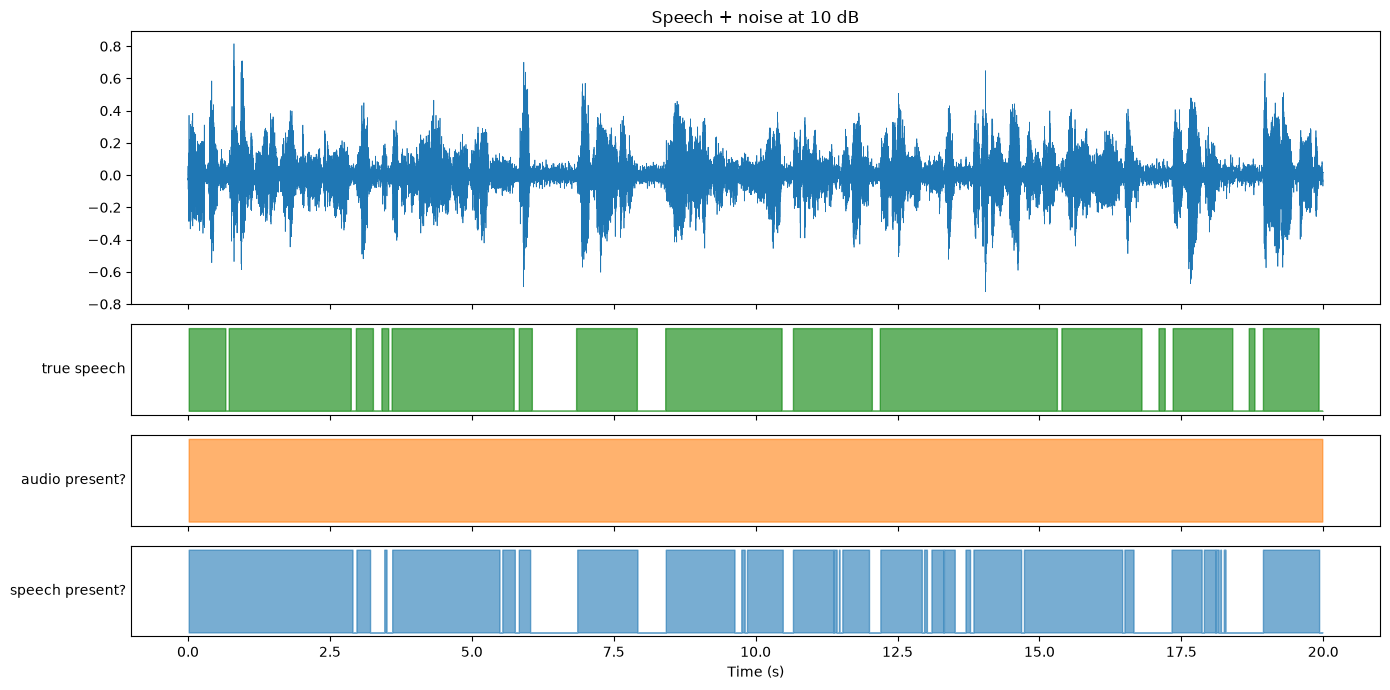

This clip, speech detector: {'accuracy': 0.904, 'balanced_acc': 0.911, 'miss_rate': 0.098, 'false_alarm': 0.081}


In [11]:
clean = load_wav(list_clips("test", "clean_speech")[0])
noise = load_wav(list_clips("test", "noise_only")[0])
noisy = mix(clean, noise,10)

feats = extract_features(noisy)
true_speech = speech_labels(clean)
energy_threshold = table2.loc[("audio present?", "energy_db"), "threshold"]
audio_decision = feats["energy_db"].values > energy_threshold
speech_decision = speech_model.predict(feats[BEST_SET].values) == 1
frame_time = (np.arange(len(feats)) * HOP + FRAME / 2) / SR

fig, axes = plt.subplots(4, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1, 1]})
axes[0].plot(np.arange(len(noisy)) / SR, noisy, linewidth=0.5); axes[0].set_title("Speech + noise at 10 dB")
for ax, decision, label, colour in [(axes[1], true_speech, "true speech", "green"),
                                    (axes[2], audio_decision, "audio present?", "tab:orange"),
                                    (axes[3], speech_decision, "speech present?", "tab:blue")]:
    ax.fill_between(frame_time, 0, decision.astype(int), step="mid", color=colour, alpha=0.6)
    ax.set_yticks([]); ax.set_ylabel(label, rotation=0, ha="right", va="center")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()

print("This clip, speech detector:", {k: round(float(v), 3) for k, v in scores(true_speech, speech_decision).items()})
display(Audio(np.clip(noisy, -1, 1), rate=SR, normalize=False))

Soru: Sayılar tamam. Peki dedektör gerçek bir kayıtta nasıl davranıyor?

Ne yapıyor:

İlk üç satır: Notebook 02'nin son hücresindeki aynı kayıt: test konuşması ve gürültüsü, 10 dB’de karıştırılmış.
true_speech: Doğru cevap; temiz kayıttan gelen etiketler.
energy_threshold: Tablo 2'de “ses var mı” için bulunan enerji eşiği (−36,6 dB).
audio_decision: “Ses var mı” kararı. Enerji eşiğin üstündeyse evet.
speech_decision: “Konuşma var mı” kararı. Hücre 6'da eğittiğimiz modelin tahmini.
Grafik: Dört şerit alt alta:
Dalga şekli.
Yeşil: konuşmanın gerçekten olduğu yerler.
Turuncu: “ses var” denen yerler.
Mavi: “konuşma var” denen yerler.
print: Bu tek kayıt için dört skor.
Son satır: Kaydı çalar; grafiğe bakarken dinleyebilirsin.

Beklenen: Dört şeritli bir grafik, bir satır skor, bir oynatıcı.

Bakacağın şey:

Mavi şerit yeşil şeride ne kadar benziyor? Nerelerde ayrışıyor?
Turuncu şerit nasıl görünüyor? Bu kayıtta her yerde gürültü olduğunu hatırla.

Şerit şerit

Yeşil (doğru cevap): Konuşmanın gerçekten olduğu yerler. Aralarda beyaz boşluklar var: 6–6,8 saniye, 7,9–8,4 saniye gibi duraklamalar.

Turuncu (ses var mı): Baştan sona dolu. Doğru: bu kayıtta her an gürültü var, duraklamalar dahil. “Ses var mı” sorusunun cevabı her yerde evet.

Mavi (konuşma var mı): Yeşile büyük ölçüde benziyor. Büyük duraklamaları (6–6,8 ve 7,9–8,4 saniye) doğru yakalamış.

Turuncu ile mavi yan yana

Proje boyunca anlattığımız ayrımın resmi bu:

Ses dedektörü duraklamalarda da “evet” diyor, çünkü gürültü var.
Konuşma dedektörü aynı duraklamalarda “hayır” diyor, çünkü gürültü konuşma değil.

Hocaya iki sorunun neden ayrı olduğunu anlatırken bu grafiği göster.

Mavi nerede yanılıyor

Kaçırdığı yerler (yeşil var, mavi yok):

9,7 saniye civarı, 11,4 saniye civarı.
12,9–13,7 saniye arasında birkaç kısa boşluk.
16,7–17,3 saniye arası.

Hepsi uzun konuşma bölümlerinin içinde. Notebook 02'nin son grafiğinde enerjinin konuşma içinde gürültü seviyesine indiği çukurlar vardı; büyük olasılıkla onlar. Kesin söylemek için iki grafiği üst üste koymak gerekir.

Yanlış alarm verdiği yer (yeşil yok, mavi var):

0,65 saniyedeki kısa duraklama. Yeşilde ince bir boşluk var, mavi onu kapatmış.
Skorlar
	Bu kayıt
balanced_acc	0,911
Kaçırma	0,098
Yanlış alarm	0,081

In [12]:
zero_db_pauses = test[(test["condition"] == "speech + noise 0 dB") & (test["speech"] == 0)]
per_clip = zero_db_pauses.groupby("clip")["predicted_speech"].mean().sort_values(ascending=False)
display(per_clip.round(2).to_frame("share of pause frames called speech (0 dB)"))

,share of pause frames called speech (0 dB)
clip,
8.wav,1.00
18.wav,0.93
14.wav,0.88
5.wav,0.75
10.wav,0.75
7.wav,0.57
19.wav,0.49
4.wav,0.48
1.wav,0.45


En kötüler: 8.wav, 18.wav, 14.wav
En iyiler: 6.wav, 17.wav, 0.wav
Kuş sesi modeli neden şaşırtıyor olabilir

Bu bir açıklama denemesi; henüz ölçmedik. Ama notebook 02'de gördüklerinle örtüşüyor:

Konuşmanın özelliği	Uğultuda var mı	Kuş sesinde var mı
Perdesi var, dalga kendini tekrar ediyor	Hayır	Evet, kuş sesi de perdeli
Zaman içinde inip çıkıyor	Hayır, sabit	Evet, aralıklı geliyor

Model konuşmayı iki şeyden tanıyordu: perdeden (harmonicity) ve zaman içindeki oynaklıktan (context). Uğultuda ikisi de yok, o yüzden kolayca reddediyor. Kuş sesinde ikisi de var. Model açısından kuş sesi, uğultudan çok konuşmaya benziyor olabilir.

In [13]:
noise_test = test[test["condition"] == "noise only"]
bird_like, hum = ["8.wav", "18.wav", "14.wav"], ["6.wav", "17.wav", "0.wav"]
columns = ["harmonicity", "centroid", "zcr", "energy_db_std", "harmonicity_std"]

compare = pd.DataFrame({
    "noise with birds (8, 18, 14)": noise_test[noise_test["clip"].isin(bird_like)][columns].median(),
    "hum (6, 17, 0)": noise_test[noise_test["clip"].isin(hum)][columns].median(),
    "speech (clean)": test[(test["klass"] == "speech") & (test["condition"] == "clean speech")][columns].median(),
})
display(compare.round(3))

,"noise with birds (8, 18, 14)","hum (6, 17, 0)",speech (clean)
harmonicity,0.205,0.237,0.512
centroid,1820.279,277.073,1097.034
zcr,0.158,0.025,0.060
energy_db_std,1.012,1.586,6.472
harmonicity_std,0.059,0.106,0.151


Ne yapıyor:

noise_test: Test verisindeki yalnız gürültü kayıtlarının parçaları.
bird_like, hum: Senin dinlediğin iki grup.
columns: Bakacağımız beş feature:
harmonicity: perde var mı.
centroid, zcr: ses ne kadar tiz.
energy_db_std: enerji çevrede ne kadar oynuyor.
harmonicity_std: harmonicity çevrede ne kadar oynuyor.
compare: Üç sütunlu tablo: kuşlu gürültü, uğultu, temiz konuşma. Her biri için tipik değer.

Nasıl okunur: Her satırda kuşlu gürültünün değeri uğultuya mı yakın, konuşmaya mı?

Kuşlu gürültü konuşmaya yakınsa → açıklama doğrulanır: model onu konuşma sanıyor çünkü feature’ları konuşmaya benziyor.
Uğultuya yakınsa → açıklama yanlış, başka bir neden aramak gerekir.

Tablo benim açıklamamı çürütüyor, ama senin gözlemini doğruluyor. İkisini ayıralım.

Tablo
Feature	Kuşlu gürültü	Uğultu	Konuşma
harmonicity	0,205	0,237	0,512
centroid	1820	277	1097
zcr	0,158	0,025	0,060
energy_db_std	1,01	1,59	6,47
harmonicity_std	0,059	0,106	0,151
Benim açıklamam yanlış çıktı

“Kuş sesi perdeli ve oynak olduğu için konuşmaya benziyor” demiştim. Sayılar bunu desteklemiyor:

harmonicity: Kuşlu gürültü 0,205, uğultu 0,237. Kuşlu olan daha perdeli değil; ikisi de konuşmanın (0,512) çok altında.
energy_db_std: Kuşlu gürültü 1,0, uğultu 1,6, konuşma 6,5. Kuşlu gürültü daha oynak değil, tersine daha düz.
harmonicity_std: Aynı durum.

Yani bu üç feature’a göre kuşlu gürültü konuşmaya hiç benzemiyor.

Senin gözlemin doğru çıktı

“Frekansı daha yüksek geliyor” demiştin. Tabloda açıkça görünüyor:

centroid: Uğultu 277 Hz, kuşlu gürültü 1820 Hz. Altı kattan fazla.
zcr: Uğultu 0,025, kuşlu gürültü 0,158. Altı kat.

Bu iki gürültü grubu birbirinden çok farklı: biri çok kalın, biri tiz. Konuşma ikisinin arasında (1097 Hz, 0,060).

Öyleyse model neden yanılıyor?

Bu kez elimizdeki sonuçlara dayanan bir açıklama var. Tablo 2'de “konuşma var mı” için bulunan kurallara bak:

Feature	Tablo 2'deki kural
centroid	517'nin üstü = konuşma
zcr	0,035'in üstü = konuşma

Model train verisinden şunu öğrenmiş: kalın ses gürültüdür, daha tiz ses konuşmadır. Bu, uğultu türü gürültüler için doğru. Ama kuşlu gürültü konuşmadan da tiz: centroid’i 1820, eşiğin çok üstünde. Bu kurallara göre “konuşma” tarafına düşüyor.

Yani olası neden: model gürültüyü “kalın ses” olarak öğrenmiş; tiz bir gürültüyle karşılaşınca onu tanıyamıyor.

Logistic regression’ın bir sınırı da burada devreye giriyor: yalnızca “ne kadar tizse o kadar konuşma” diyebiliyor. “Konuşma orta tizlikte olur, bundan fazlası yine gürültüdür” diyemiyor.

Train noise clips with centroid above 1000 Hz: 10 of 30
Test  noise clips with centroid above 1000 Hz: 8 of 20


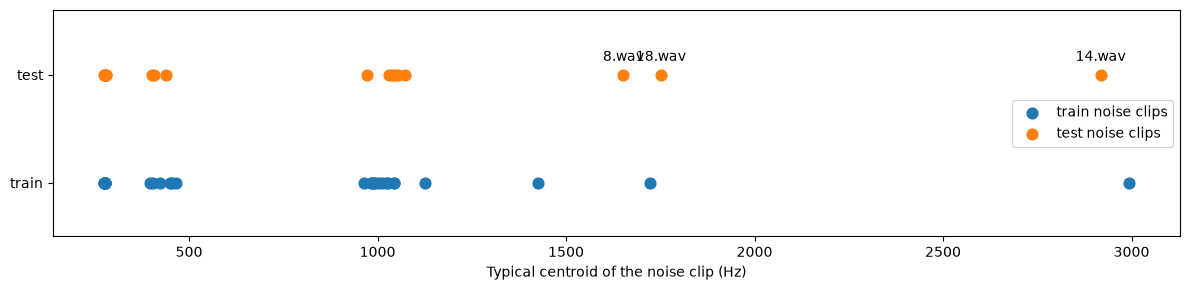

clip,6.wav,1.wav,9.wav,0.wav,17.wav,11.wav,5.wav,13.wav,7.wav,4.wav,12.wav,19.wav,16.wav,2.wav,3.wav,10.wav,15.wav,8.wav,18.wav,14.wav
centroid (Hz),275.0,276.0,277.0,278.0,278.0,278.0,280.0,280.0,401.0,408.0,439.0,973.0,1031.0,1038.0,1047.0,1055.0,1072.0,1652.0,1751.0,2918.0


In [14]:
def noise_brightness(table):
    """Typical centroid (Hz) of every noise-only clip, sorted from dull to bright."""
    noise_part = table[table["condition"] == "noise only"]
    return noise_part.groupby("clip")["centroid"].median().sort_values()

train_centroid = noise_brightness(train)
test_centroid = noise_brightness(test)

print("Train noise clips with centroid above 1000 Hz:", (train_centroid > 1000).sum(), "of", len(train_centroid))
print("Test  noise clips with centroid above 1000 Hz:", (test_centroid > 1000).sum(), "of", len(test_centroid))

fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(train_centroid.values, np.zeros(len(train_centroid)), label="train noise clips", s=60)
ax.scatter(test_centroid.values, np.ones(len(test_centroid)), label="test noise clips", s=60)
for clip in ["8.wav", "18.wav", "14.wav"]:
    ax.annotate(clip, (test_centroid[clip], 1), textcoords="offset points", xytext=(0, 10), ha="center")
ax.set_yticks([0, 1]); ax.set_yticklabels(["train", "test"]); ax.set_ylim(-0.5, 1.6)
ax.set_xlabel("Typical centroid of the noise clip (Hz)"); ax.legend(loc="center right")
plt.tight_layout(); plt.show()

display(test_centroid.round(0).to_frame("centroid (Hz)").T)

Deney 1: Model eğitilirken tiz gürültü gördü mü?

Mantık: Model yalnızca train verisinden öğreniyor. Train’deki 30 gürültü kaydının çoğu kalın uğultuysa, model tiz gürültünün ne olduğunu hiç öğrenmemiştir. O zaman açıklamamız güçlenir. Train’de de bolca tiz gürültü varsa açıklama zayıflar; model onları görmüş ama yine de öğrenememiş demektir.
Ne yapıyor:

noise_brightness(table): Küçük bir yardımcı fonksiyon. Tablodan yalnız gürültü kayıtlarını alır, her kayıt için centroid’in tipik değerini hesaplar, kalından tize sıralar. Centroid’i “sesin ne kadar tiz olduğu” ölçüsü olarak kullanıyoruz.
train_centroid, test_centroid: Aynı hesabı train’deki 30 ve test’teki 20 gürültü kaydı için yapar.
İki print: Kaç kaydın centroid’i 1000 Hz’in üstünde, yani “tiz” sayılabilir. 1000'i sınır aldım çünkü konuşmanın tipik değeri 1097'ydi.
Grafik: Her nokta bir gürültü kaydı. Alt sırada train kayıtları, üst sırada test kayıtları. Sağa gittikçe tiz. Senin bulduğun üç kötü kayıt (8, 18, 14) adlarıyla işaretli.
Son satır: Test kayıtlarının centroid değerlerini tek satırlık tablo olarak yazar.

Bakacağın şey:

Train’de 1000 Hz’in üstünde kaç kayıt var? Test’te kaç?
Grafikte 8, 18 ve 14 nerede? En sağda mı?
Alt sırada (train) o bölgede nokta var mı, yoksa boş mu?

In [15]:
zero_db = test[test["condition"] == "speech + noise 0 dB"]
bright = zero_db["clip"].isin(["8.wav", "18.wav", "14.wav"]).values
pause = (zero_db["speech"] == 0).values

no_brightness = [f for f in SCALAR_FEATURES if f not in ("centroid", "zcr")]
candidates = {
    "energy only": ["energy_db"],
    "7 scalar": SCALAR_FEATURES,
    "scalar without centroid, zcr": no_brightness,
    "all 33 (best set)": BEST_SET,
}

rows = []
for name, features in candidates.items():
    model = fit_model(train, features, "speech")
    predicted = model.predict(zero_db[features].values)
    rows.append({
        "feature set": name,
        "false alarm, bright noise (8, 18, 14)": predicted[pause & bright].mean(),
        "false alarm, other noise": predicted[pause & ~bright].mean(),
        "speech found": predicted[~pause].mean(),
    })
display(pd.DataFrame(rows).set_index("feature set").round(3))

,"false alarm, bright noise (8, 18, 14)","false alarm, other noise",speech found
feature set,,,
energy only,0.989,1.000,1.000
7 scalar,0.987,0.753,0.969
"scalar without centroid, zcr",0.986,0.861,0.977
all 33 (best set),0.943,0.381,0.944


Deney 2: Tizlik gerçekten neden mi?

Şu ana kadar bir ilişki gösterdik: tiz gürültüde model kötü. Bunun neden olduğunu göstermek için modelden tizlik bilgisini çıkarıp bakmalıyız: centroid ve ZCR olmadan model tiz gürültüde düzeliyor mu?
Ne yapıyor:

zero_db: Test verisinden yalnızca 0 dB karışımlar.
bright: Parça tiz gürültülü üç kayıttan birine mi ait? (evet / hayır)
pause: Parça bir duraklama mı, yani konuşma-dışı mı?
no_brightness: Yedi skaler feature’dan centroid ve ZCR çıkarılmış hali; geriye beş feature kalıyor.
candidates: Karşılaştırılacak dört model.
Döngü: Her model için train’de eğitir, 0 dB karışımlarda tahmin yapar ve üç sayı hesaplar:
Tiz gürültülü kayıtlarda duraklamaların yüzde kaçına “konuşma” dendi.
Diğer kayıtlarda duraklamaların yüzde kaçına “konuşma” dendi.
Konuşmanın yüzde kaçı bulundu (modelin başka yerde bozulmadığını görmek için).

Nasıl okunur: İlk iki sütunda düşük sayı iyi, üçüncüde yüksek sayı iyi.

“0 dB’de enerji tek başına her şeye konuşma diyor, çünkü gürültü konuşma kadar yüksek. Diğer feature’lar bunu kalın gürültülerde düzeltebiliyor: yanlış alarm 1,00'dan 0,38'e iniyor, en büyük katkı context’ten. Ama tiz gürültüde hiçbir feature düzeltemiyor, yanlış alarm 0,94'te kalıyor. Model gürültüyü kısık ya da kalın olmasından tanıyor; gür ve tiz bir gürültüyü tanıyacak feature’ı yok.”

In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier

tree_model = HistGradientBoostingClassifier(max_iter=200, class_weight="balanced", random_state=0)
tree_model.fit(train[BEST_SET].values, train["speech"].values)

rows = []
for name, model in [("logistic regression, 33 features", speech_model),
                    ("gradient boosting, 33 features", tree_model)]:
    predicted = model.predict(zero_db[BEST_SET].values)
    rows.append({
        "model": name,
        "false alarm, bright noise (8, 18, 14)": predicted[pause & bright].mean(),
        "false alarm, other noise": predicted[pause & ~bright].mean(),
        "speech found": predicted[~pause].mean(),
        "balanced_acc, whole test set": scores(test["speech"].values, model.predict(test[BEST_SET].values))["balanced_acc"],
    })
display(pd.DataFrame(rows).set_index("model").round(3))

,"false alarm, bright noise (8, 18, 14)","false alarm, other noise",speech found,"balanced_acc, whole test set"
model,,,,
"logistic regression, 33 features",0.943,0.381,0.944,0.922
"gradient boosting, 33 features",0.907,0.235,0.936,0.934


Deney 3: Başka bir model düzeltebilir mi?

Daha önce “başka model denemedik” demiştim ve ertelemiştik. Şimdi denemek için somut bir neden var.

Tabloya göre tiz gürültünün harmonicity’si düşük (0,205; konuşmanınki 0,512). Yani onu konuşmadan ayıracak bilgi feature’ların içinde aslında var. Logistic regression bunu kullanamıyor olabilir, çünkü yalnızca toplama yapabiliyor. “Enerji yüksek ama harmonicity düşükse gürültüdür” gibi birleşik bir kuralı öğrenemiyor.

Böyle kuralları öğrenebilen bir model deneyelim: karar ağaçlarından oluşan bir model (gradient boosting). Aynı feature’lar, yalnızca model farklı.
Ne yapıyor:

HistGradientBoostingClassifier: Çok sayıda küçük karar ağacı kuran bir model. Her ağaç “enerji −30'un üstünde mi? evetse harmonicity 0,3'ün üstünde mi?” gibi art arda sorular sorar. Bu sayede feature’ların birleşimlerine bakabilir.
max_iter=200: 200 ağaç kur. class_weight="balanced": Büyük sınıfı kayırma. random_state=0: Her çalıştırmada aynı sonucu ver.
.fit(...): Train verisinde eğitir. Bir dakika kadar sürebilir.
Döngü: İki modeli (eski ve yeni) aynı ölçülerle karşılaştırır. Son sütun bütün test verisindeki genel sonuç; Tablo 3'teki 0,922 ile karşılaştırmak için.

Bakacağın şey:

Tiz gürültüde yanlış alarm 0,943'ten düşüyor mu?
Kalın gürültüde 0,381'den düşüyor mu?
Genel sonuç 0,922'den yükseliyor mu?

Olası sonuçlar:

Tiz gürültüde belirgin düşerse → bilgi feature’larda varmış, eksik olan modelmiş.
Düşmezse → sorun modelde değil; train’de yalnızca üç tiz gürültü kaydı olması ya da feature’ların yetersizliği daha olası neden.


In [17]:
pause_counts = zero_db[pause].groupby("clip").size()
print("Pause frames in the three bright-noise clips:")
print(pause_counts[["8.wav", "18.wav", "14.wav"]].to_string())
print()
print("Pause frames per clip, all 20 clips: smallest", pause_counts.min(),
      "| typical", int(pause_counts.median()), "| largest", pause_counts.max())

Pause frames in the three bright-noise clips:
clip
8.wav     399
18.wav    294
14.wav    307

Pause frames per clip, all 20 clips: smallest 233 | typical 306 | largest 415


In [18]:
train_zero = train[train["condition"] == "speech + noise 0 dB"]
train_pause = (train_zero["speech"] == 0).values
bright_train_clips = train_centroid[train_centroid > 1400].index.tolist()
train_bright = train_zero["clip"].isin(bright_train_clips).values
print("Bright noise clips in train:", bright_train_clips)

rows = []
for name, model in [("logistic regression", speech_model), ("gradient boosting", tree_model)]:
    seen = model.predict(train_zero[BEST_SET].values)
    new = model.predict(zero_db[BEST_SET].values)
    rows.append({
        "model": name,
        "bright noise, seen in training": seen[train_pause & train_bright].mean(),
        "bright noise, new (test)": new[pause & bright].mean(),
        "other noise, seen in training": seen[train_pause & ~train_bright].mean(),
        "other noise, new (test)": new[pause & ~bright].mean(),
    })
display(pd.DataFrame(rows).set_index("model").round(3))

Bright noise clips in train: ['18.wav', '26.wav', '20.wav']


,"bright noise, seen in training","bright noise, new (test)","other noise, seen in training","other noise, new (test)"
model,,,,
logistic regression,0.517,0.943,0.358,0.381
gradient boosting,0.117,0.907,0.137,0.235


Bu tablo iki adaydan birini açıkça öne çıkarıyor: sorun büyük ölçüde veri.

Tablo (0 dB, duraklamalara “konuşma” deme oranı)
Model	Tiz, eğitimde görülmüş	Tiz, yeni	Diğer, görülmüş	Diğer, yeni
Logistic regression	0,517	0,943	0,358	0,381
Gradient boosting	0,117	0,907	0,137	0,235
Önce karşılaştırma sütunları

Diğer (kalın) gürültüler: Görülmüş ile yeni arasında fark küçük.

Logistic regression: 0,358 ve 0,381. Neredeyse aynı.
Gradient boosting: 0,137 ve 0,235. Biraz fark var.

Yani model kalın gürültülerde öğrendiğini yeni kayıtlara aktarabiliyor. Notebook 02'de gördüğümüz kümelenmeyle uyumlu: kalın gürültüler birbirine çok benziyor, birini gören diğerini tanıyor.

Asıl sonuç: tiz gürültüler

Görülmüş ile yeni arasında uçurum var.

Logistic regression: 0,517'den 0,943'e.
Gradient boosting: 0,117'den 0,907'ye.

Koyduğumuz kurala göre: birincisi düşük, ikincisi yüksek → veri sorunu. Model eğitimde gördüğü tiz gürültüleri reddedebiliyor, hiç görmediklerini reddedemiyor.

Ne anlama geliyor

Bilgi feature’larda var. Gradient boosting, gördüğü tiz gürültülerde yanlış alarmı 0,12'ye indirebiliyor. Yani bu 33 feature, o gürültüleri konuşmadan ayırmaya yetiyor.

Ama öğrendiği şey o üç kayda özgü. Train’deki tiz gürültüler (18, 26, 20) ile test’tekiler (8, 18, 14) centroid olarak benzer tizlikte. Buna rağmen birinden öğrenilen diğerine geçmiyor. Demek ki “tiz gürültü” tek bir tür değil; her biri farklı bir ses ve model üç örnekten genel bir kural çıkaramıyor.

Kalın gürültülerle karşılaştır: train’de onlardan 20'den fazla var ve birbirine çok benziyorlar. Model onları öğrenmiş. Tiz gürültüden yalnızca üç tane var ve birbirine benzemiyorlar.